# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [61]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

18706

In [62]:
# Load dataset
data_path = '/home/sara/lcpB/Computational-Physics-2026/Astrophysical-Objects-Recognition/stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

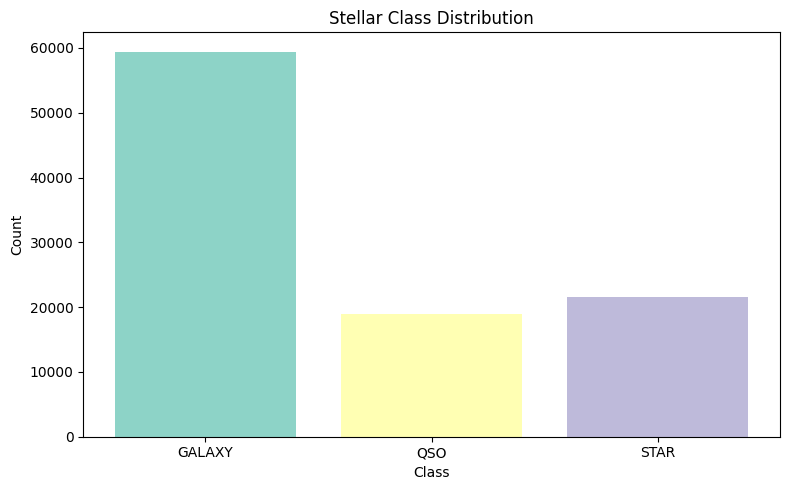

In [63]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [64]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [65]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [66]:
# dataframe completo con target
X_full = pd.DataFrame(X_test, columns=feature_names)
X_full["class"] = label_encoder.inverse_transform(y_test)

# feature colore
color_features = ["u_g", "g_r", "r_i", "i_z"]

# media dei colori per classe
color_table = X_full.groupby("class")[color_features].mean()

print(color_table)

             u_g       g_r       r_i       i_z
class                                         
GALAXY  0.213888  0.492081  0.453777  0.369712
QSO    -0.807408 -1.013359 -0.863616 -0.505106
STAR    0.114865 -0.504203 -0.510716 -0.542782


In [13]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.85%  P=0.81  R=0.82  F1=0.81


KeyboardInterrupt: 

In [ ]:
# Train Voting Classifier utilizing the trained models
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 106479, number of used features: 9
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=92.63%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=88.75%  P=0.85  R=0.86  F1=0.85


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Train PyTorch Neural Network
input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

nn_model = sc.train_neural(
    train_loader=train_loader,
    val_loader=val_loader,
    input_size=input_size,
    num_classes=num_classes,
    num_epochs=10,
    lr=0.001
)


Epoch  1/10  loss=0.6175  val_acc=81.58%
Epoch  2/10  loss=0.4939  val_acc=85.24%
Epoch  3/10  loss=0.4677  val_acc=85.06%
Epoch  4/10  loss=0.4542  val_acc=83.90%
Epoch  5/10  loss=0.4448  val_acc=85.47%
Epoch  6/10  loss=0.4370  val_acc=85.34%
Epoch  7/10  loss=0.4309  val_acc=84.94%
Epoch  8/10  loss=0.4256  val_acc=85.16%
Epoch  9/10  loss=0.4210  val_acc=85.98%
Epoch 10/10  loss=0.4164  val_acc=85.50%


In [ ]:
# Base inference on test set
import torch 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier:
  Accuracy  : 88.55%
  Precision: 0.8496
  Recall   : 0.8540
  F1       : 0.8508
  Confusion Matrix:
[[11087   404   340]
 [  257  3213   316]
 [  404   559  3339]]

Neural Network:
  Accuracy  : 85.95%
  Precision: 0.8145
  Recall   : 0.8390
  F1       : 0.8254
  Confusion Matrix:
[[10562   587   682]
 [  221  3155   410]
 [  377   522  3403]]


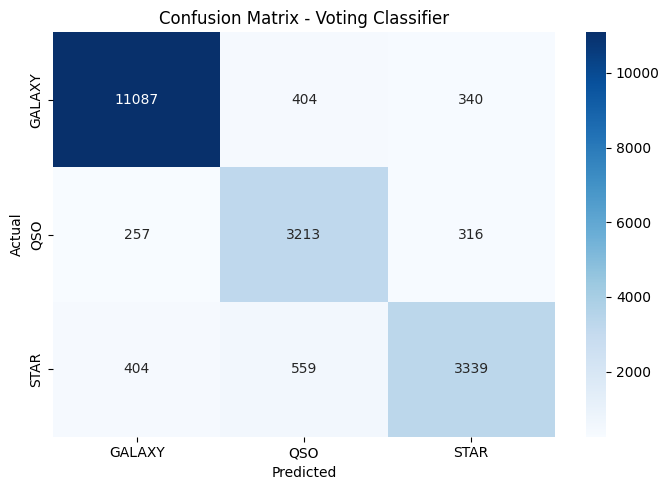

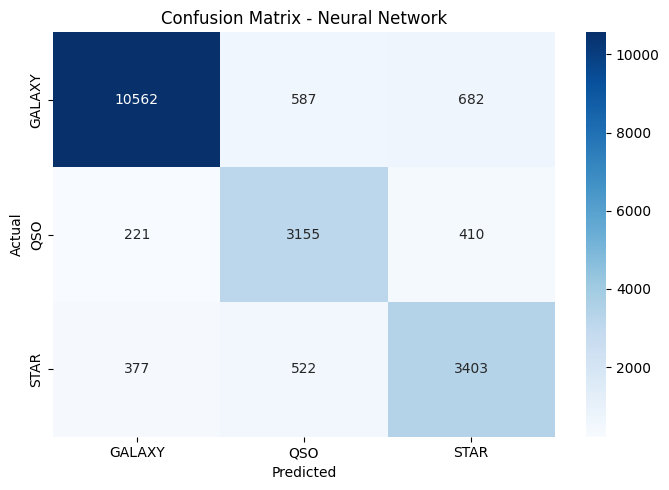

In [ ]:
# Confusion Matrices
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

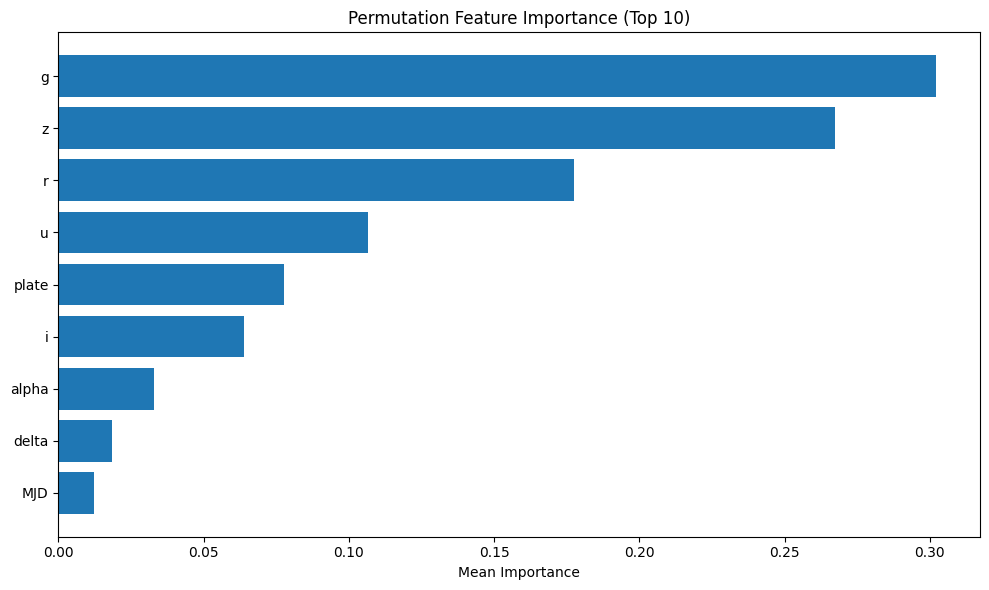

Feature Importance Scores:
g: 0.3022
z: 0.2673
r: 0.1774
u: 0.1066
plate: 0.0775
i: 0.0640
alpha: 0.0330
delta: 0.0185
MJD: 0.0121


In [ ]:
# Feature Importance (using permutation importance on the Voting Classifier)
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")


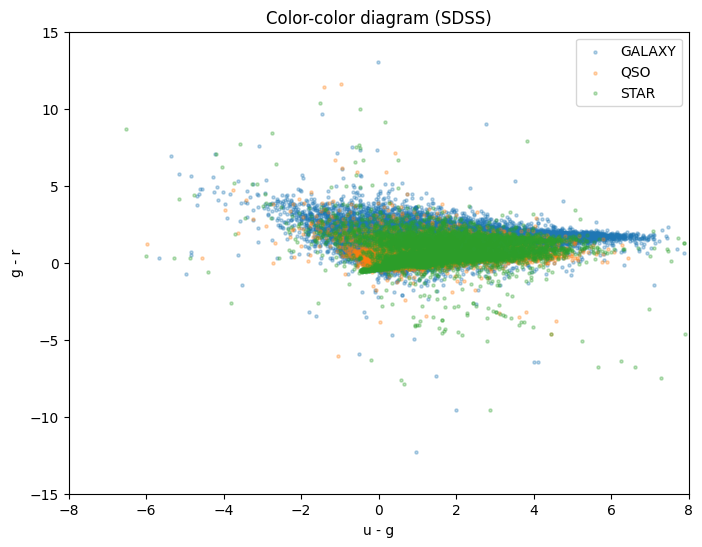

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

star = pd.read_csv(data_path)

# pulizia minima (fondamentale)
star = star.dropna(subset=['u','g','r','class'])

# indici di colore
star['u_g'] = star['u'] - star['g']
star['g_r'] = star['g'] - star['r']

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()

## XGBoost

In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

params = {"n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [49]:
xgb_final = XGBClassifier(**best_params_xgb)

xgb_final.fit(X_train, y_train)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)
#print("Training Metrics:",train_metrics_xgb)
#print("Validation Metrics:",val_metrics_xgb)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)

[Training] Acc=92.1634% P=0.9217 R=0.9216 F1=0.9215
Confusion Matrix:
[[30713   908   723]
 [ 1504 29454  1386]
 [ 1130  1953 29261]]

[Validation] Acc=90.3215% P=0.8733 R=0.8805 F1=0.8763
Confusion Matrix:
[[10141   357   283]
 [  216  3097   235]
 [  275   401  3252]]


XGBoost:
  Accuracy  : 90.62%
  Precision: 0.8769
  Recall   : 0.8846
  F1       : 0.8803
  Confusion Matrix:
[[10148   361   272]
 [  224  3083   241]
 [  249   366  3313]]


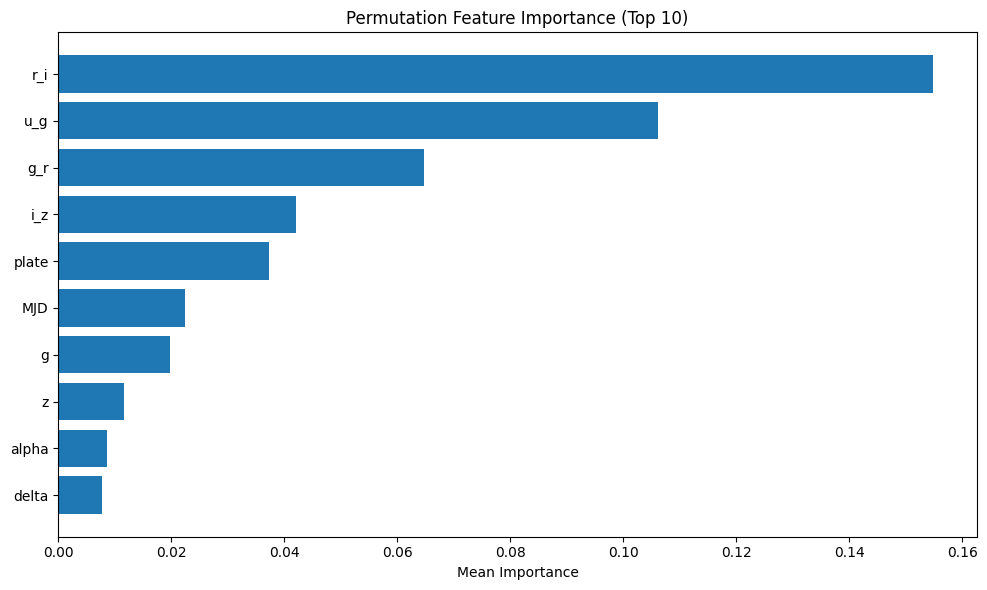

Feature Importance Scores:
r_i: 0.1548
u_g: 0.1061
g_r: 0.0646
i_z: 0.0421
plate: 0.0373
MJD: 0.0224
g: 0.0197
z: 0.0116
alpha: 0.0086
delta: 0.0077
r: 0.0066
i: 0.0066
u: 0.0040


In [50]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb = sc.compute_permutation_importance(xgb_final, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp_xgb, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb.items():
    print(f"{feat}: {val:.4f}")


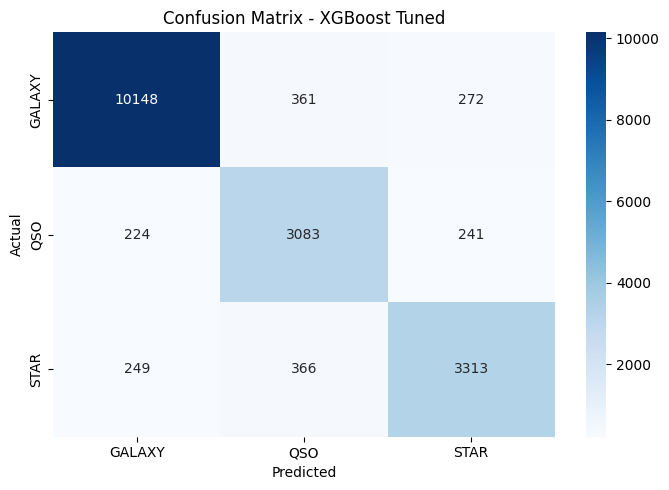

In [51]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')


SHAP summary for class: GALAXY


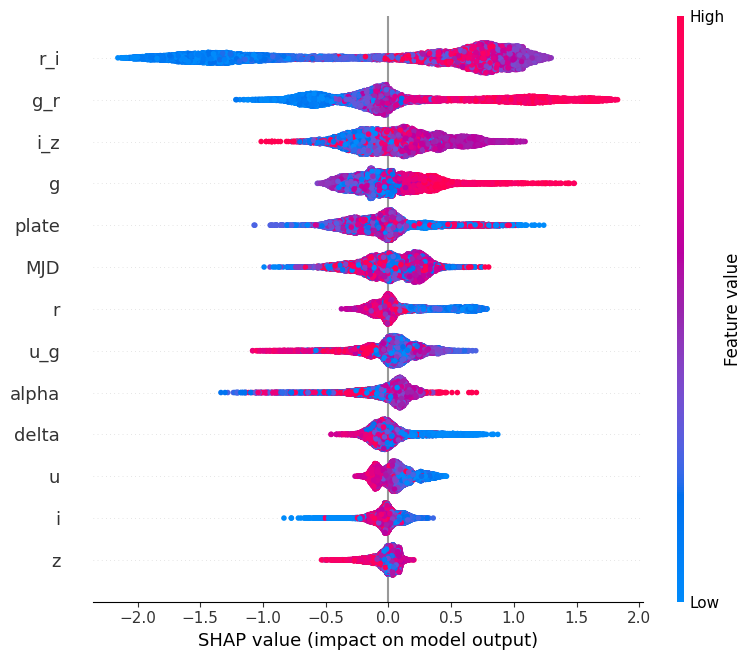


SHAP summary for class: QSO


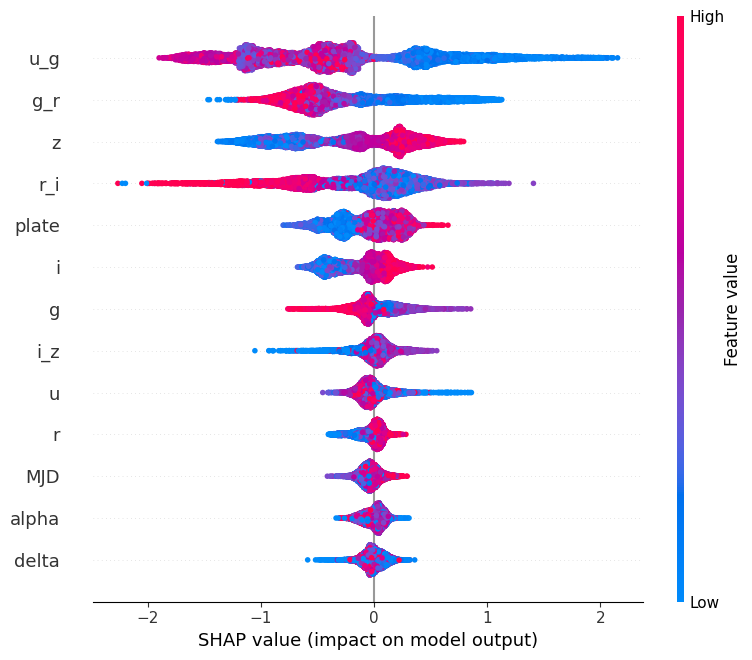


SHAP summary for class: STAR


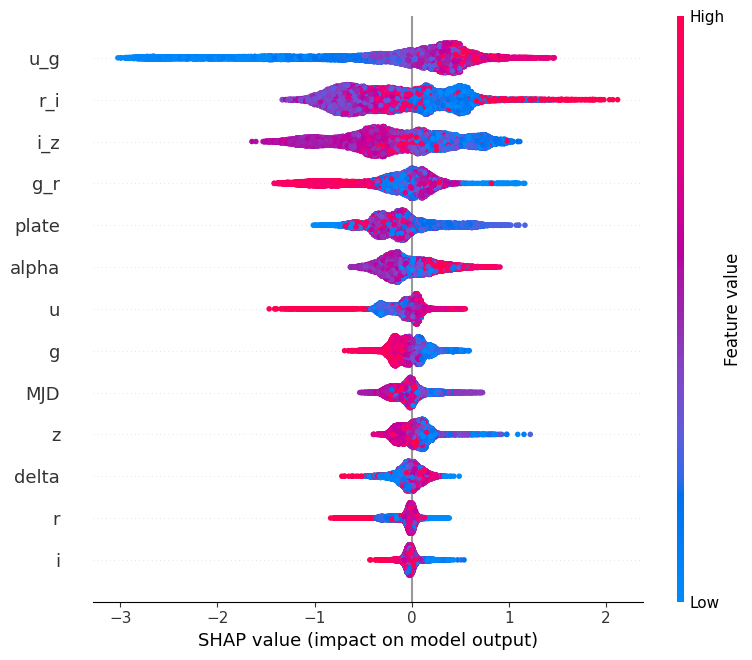

In [ ]:
import shap

# dataframe
X_test_d = pd.DataFrame(X_test, columns=feature_names)
# explainer
explainer = shap.TreeExplainer(xgb_final)
# shap values
shap_values = explainer.shap_values(X_test_d)

classes = label_encoder.classes_

for i, cls in enumerate(classes):
    print(f"\nSHAP summary for class: {cls}")
    shap.summary_plot(shap_values[:, :, i], X_test_d)


#shap.dependence_plot("feature_name", shap_values, X_test)

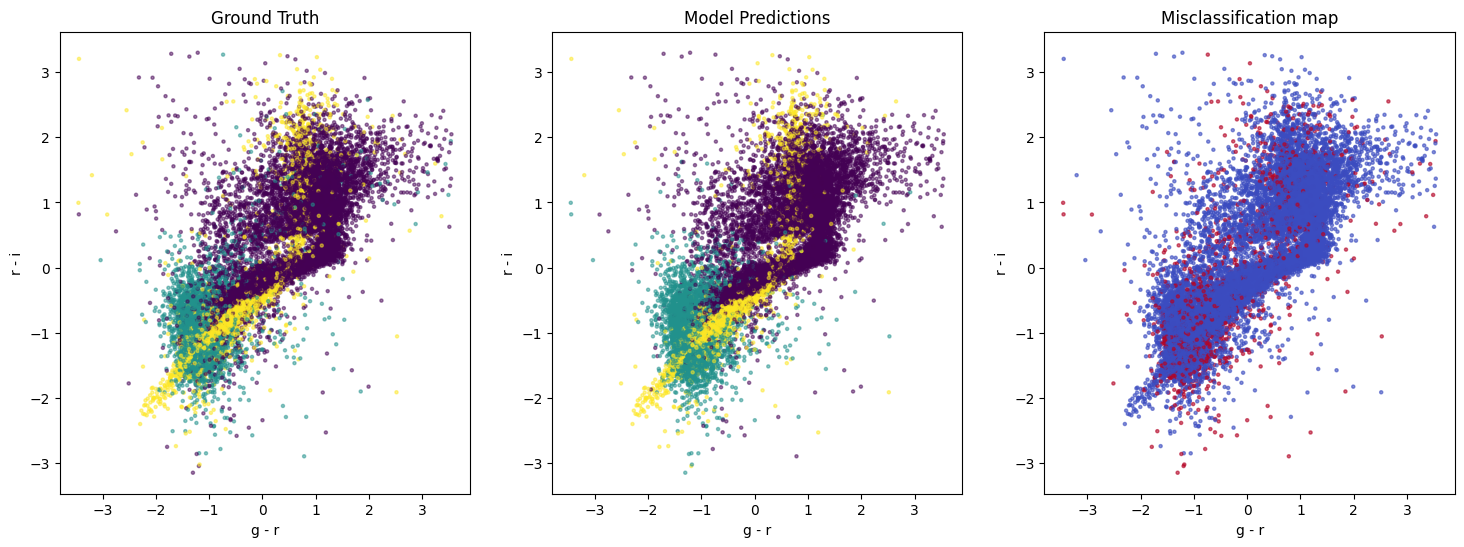

In [56]:
fig, (ax0, ax1, ax2) = plt.subplots(1,3, figsize=(18,6))
X_test_d = pd.DataFrame(X_test, columns=feature_names)
X = X_test_d.copy()   
 
ax0.scatter(X["g_r"], X["r_i"], c=y_test, cmap="viridis", s=5, alpha=0.5)
ax0.set_title("Ground Truth")
ax0.set_xlabel("g - r")
ax0.set_ylabel("r - i")

ax1.scatter( X["g_r"],  X["r_i"],  c=y_test_pred_xgb, cmap="viridis", s=5,  alpha=0.5)
ax1.set_title("Model Predictions")
ax1.set_xlabel("g - r")
ax1.set_ylabel("r - i")

errors = y_test_pred_xgb != y_test
ax2.scatter(X["g_r"], X["r_i"],  c=errors, cmap="coolwarm",  s=5,  alpha=0.6)
ax2.set_title("Misclassification map")
ax2.set_xlabel("g - r")
ax2.set_ylabel("r - i")

plt.show()

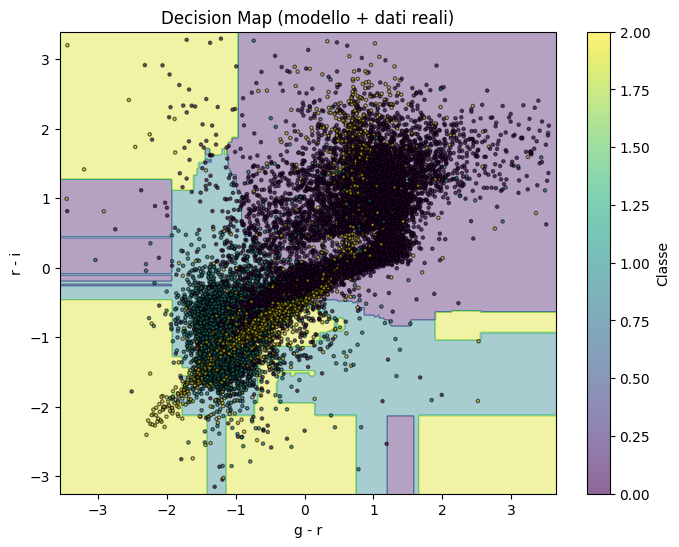

In [ ]:
X = X_test_d.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = xgb_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()

## Light GBM

In [15]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=-1)
params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_lgbm)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 64688, number of used features: 13
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Start training from score -1.098643
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.101238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 64688, number of used features: 13
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.113213 seconds.
You can set `force_col_wise=true` to remove the 

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.182420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 64688, number of used features: 13
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Start training from score -1.098643
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.206625 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 64688, number of used features: 13
[LightGBM] [Info] Start training from score -1.098643
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Start training from score -1.098597


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.245412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 64688, number of used features: 13
[LightGBM] [Info] Start training from score -1.098597
[LightGBM] [Info] Start training from score -1.098643
[LightGBM] [Info] Start training from score -1.098597


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [21]:
best_params_lgbm.pop("n_estimators", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=500)

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Training] Acc=94.1576% P=0.9417 R=0.9416 F1=0.9416
Confusion Matrix:
[[31002   763   579]
 [ 1205 30181   958]
 [  826  1338 30180]]

[Validation] Acc=90.5242% P=0.8759 R=0.8823 F1=0.8786
Confusion Matrix:
[[10163   351   267]
 [  226  3084   238]
 [  260   388  3280]]



/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM:
  Accuracy  : 90.79%
  Precision: 0.8792
  Recall   : 0.8847
  F1       : 0.8816
  Confusion Matrix:
[[10192   348   241]
 [  228  3067   253]
 [  248   363  3317]]


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

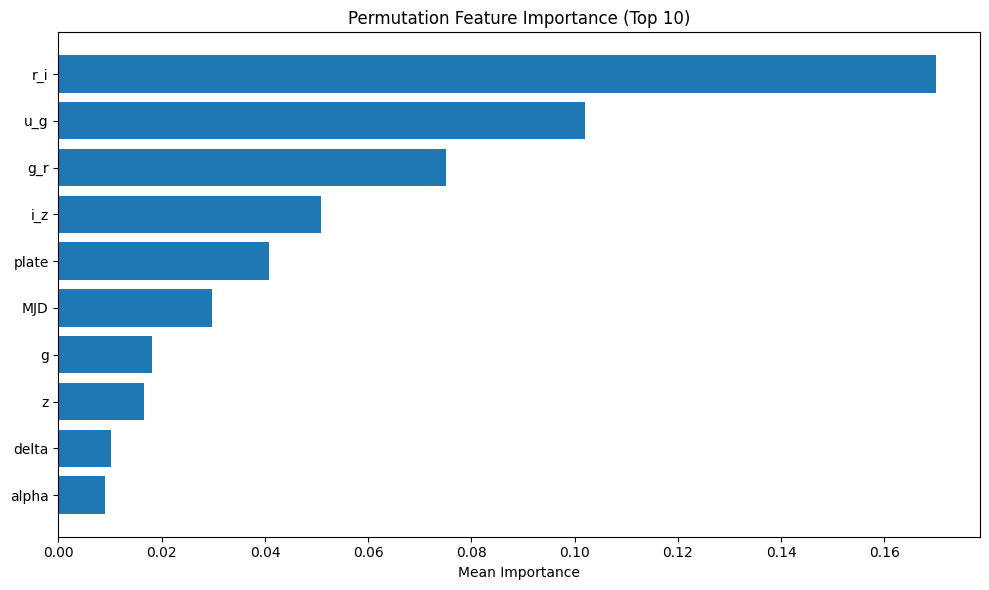

Feature Importance Scores:
r_i: 0.1700
u_g: 0.1020
g_r: 0.0751
i_z: 0.0509
plate: 0.0408
MJD: 0.0298
g: 0.0180
z: 0.0167
delta: 0.0102
alpha: 0.0091
i: 0.0072
r: 0.0052
u: 0.0049


In [22]:
# Feature Importance (using permutation importance on the LGBM Classifier)
imp_lgbm = sc.compute_permutation_importance(lgbm_final, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp_lgbm, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_lgbm.items():
    print(f"{feat}: {val:.4f}")


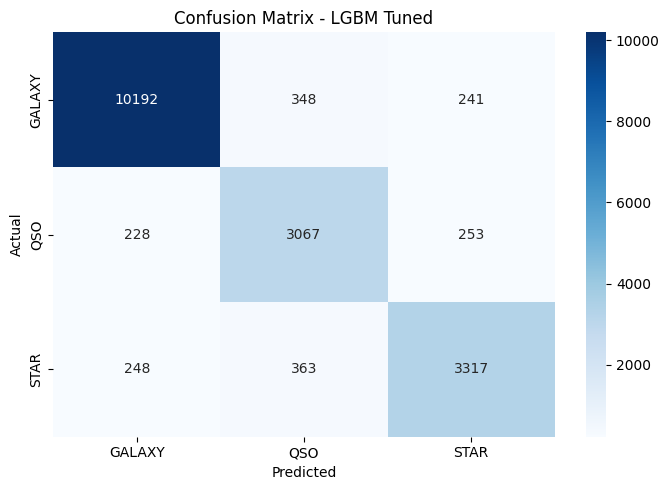

In [23]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LGBM Tuned')


SHAP summary for class: GALAXY


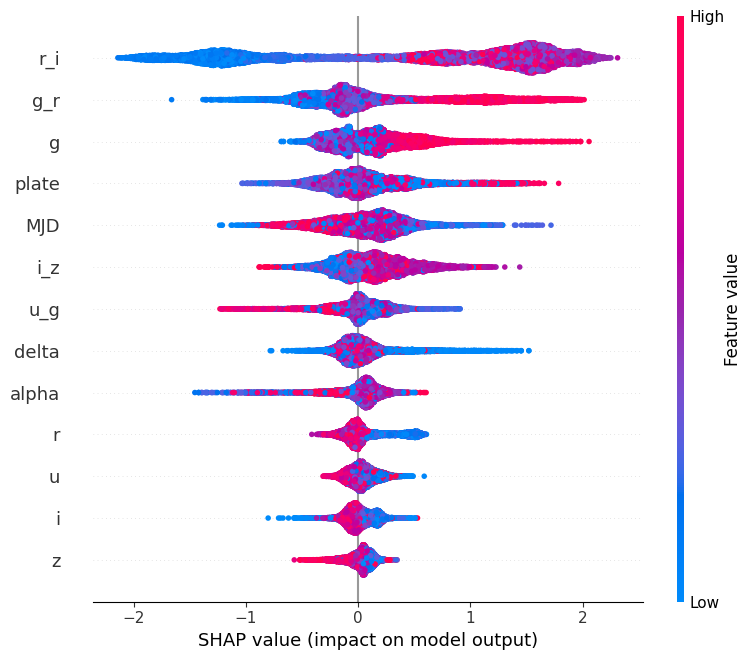


SHAP summary for class: QSO


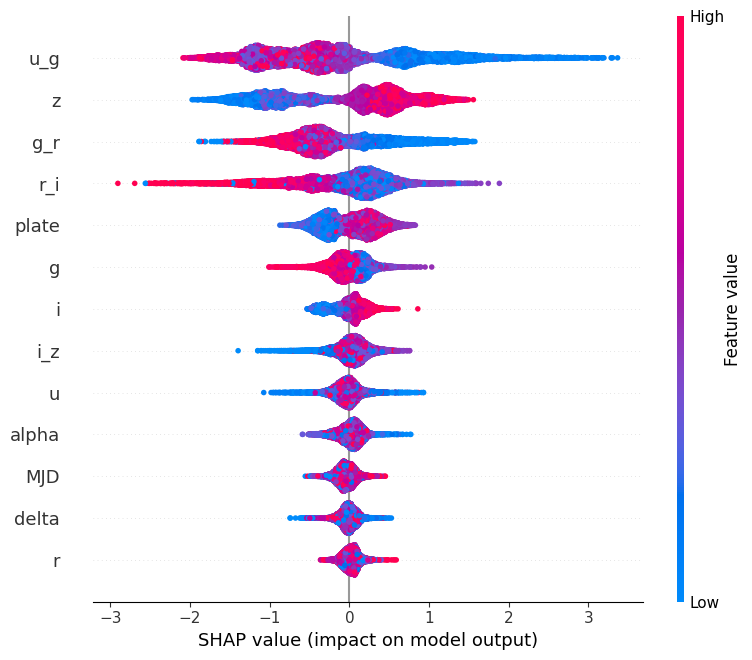


SHAP summary for class: STAR


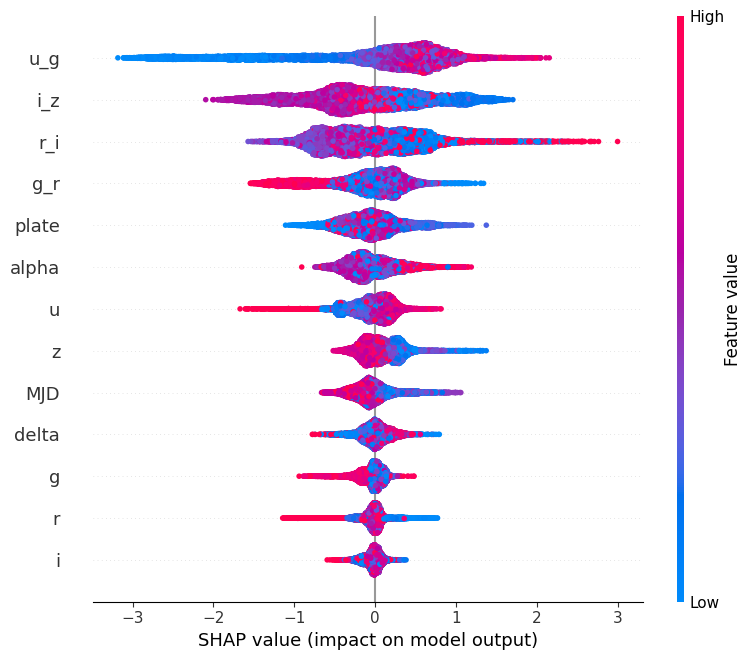

In [67]:
import shap

# dataframe
X_test_d = pd.DataFrame(X_test, columns=feature_names)
# explainer
explainer = shap.TreeExplainer(lgbm_final)
# shap values
shap_values = explainer.shap_values(X_test_d)

classes = label_encoder.classes_

for i, cls in enumerate(classes):
    print(f"\nSHAP summary for class: {cls}")
    shap.summary_plot(shap_values[:, :, i], X_test_d)


#shap.dependence_plot("feature_name", shap_values, X_test)

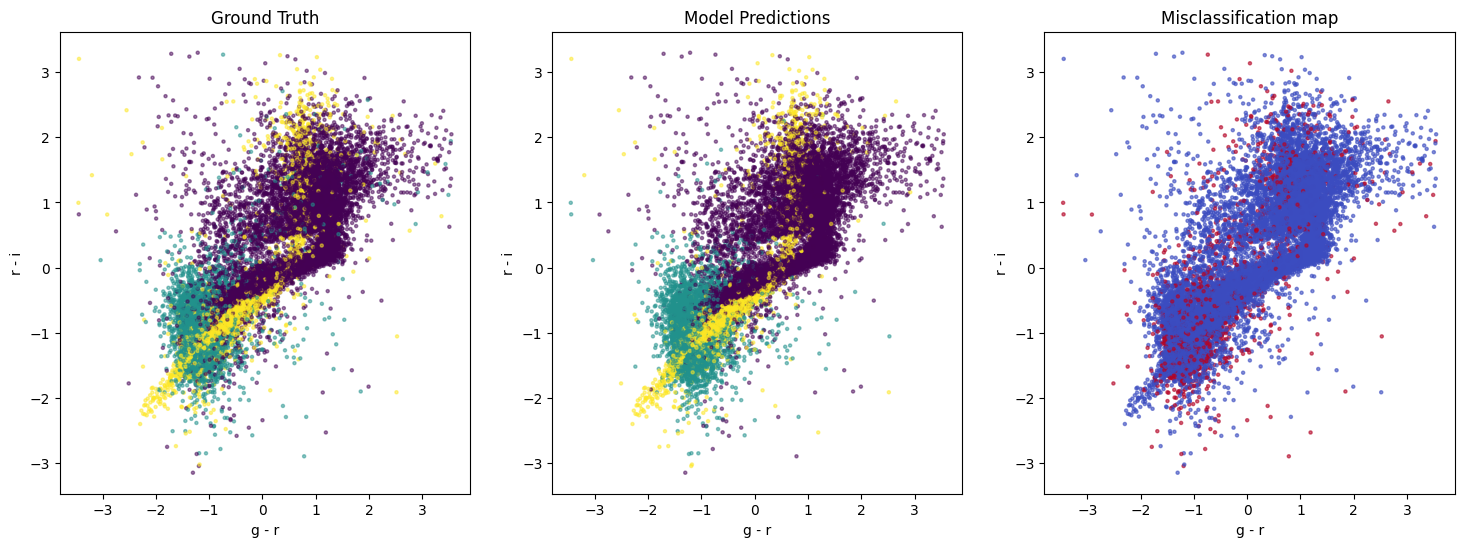

In [68]:
fig, (ax0, ax1, ax2) = plt.subplots(1,3, figsize=(18,6))
X_test_d = pd.DataFrame(X_test, columns=feature_names)
X = X_test_d.copy()   
 
ax0.scatter(X["g_r"], X["r_i"], c=y_test, cmap="viridis", s=5, alpha=0.5)
ax0.set_title("Ground Truth")
ax0.set_xlabel("g - r")
ax0.set_ylabel("r - i")

ax1.scatter( X["g_r"],  X["r_i"],  c=y_test_pred_lgbm, cmap="viridis", s=5,  alpha=0.5)
ax1.set_title("Model Predictions")
ax1.set_xlabel("g - r")
ax1.set_ylabel("r - i")

errors = y_test_pred_lgbm != y_test
ax2.scatter(X["g_r"], X["r_i"],  c=errors, cmap="coolwarm",  s=5,  alpha=0.6)
ax2.set_title("Misclassification map")
ax2.set_xlabel("g - r")
ax2.set_ylabel("r - i")

plt.show()

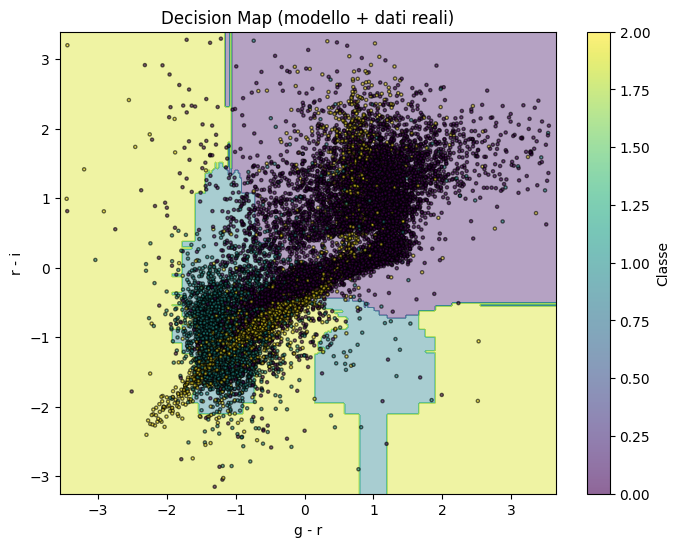

In [69]:
X = X_test_d.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = lgbm_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()